In [2]:
!pip install shap



   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [11]:
# Running  day2 to get X_train, X_val, y_train, y_val
%run day2.ipynb

from xgboost import XGBRegressor

# Fit your chosen model
model = XGBRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# If X_val is large, sample 2,000 rows so SHAP finishes in seconds
X_sample = X_val.sample(n=min(2000, len(X_val)), random_state=42)
y_sample = y_val.loc[X_sample.index]

| Model         |    RMSE |     MAE |   Training Time (s) |   Peak Memory (MB) |
|:--------------|--------:|--------:|--------------------:|-------------------:|
| Random Forest | 465.979 | 112.33  |                1.92 |              11.8  |
| XGBoost       | 470.212 | 148.646 |                0.17 |               4.16 |
| LightGBM      | 542.349 | 178.962 |                0.19 |               0    |
| CatBoost      | 484.363 | 170.24  |                0.38 |              14.09 |


In [13]:
# Task 2

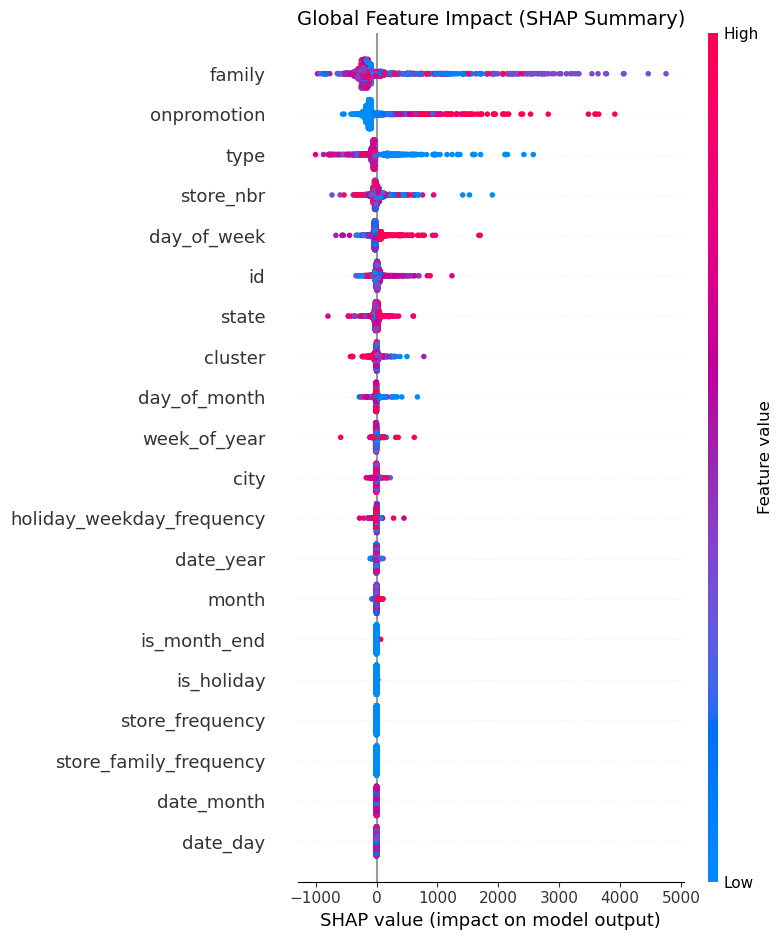

In [17]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Initialize TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

# 1. Global Beeswarm Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("Global Feature Impact (SHAP Summary)", fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# 2. Pick 3 specific observations
preds = model.predict(X_sample)
residuals = np.abs(y_sample.values - preds)

idx_typical = int(np.argmin(residuals))   # Best predicted (typical)
idx_high_err = int(np.argmax(residuals))  # Worst predicted (high error)


In [27]:
# Edge case: high promotion SKU
if 'onpromotion' in X_sample.columns and (X_sample['onpromotion'] > 0).any():
    idx_edge = int(np.argmax(X_sample['onpromotion'].values))
else:
    idx_edge = int(len(X_sample) // 2)


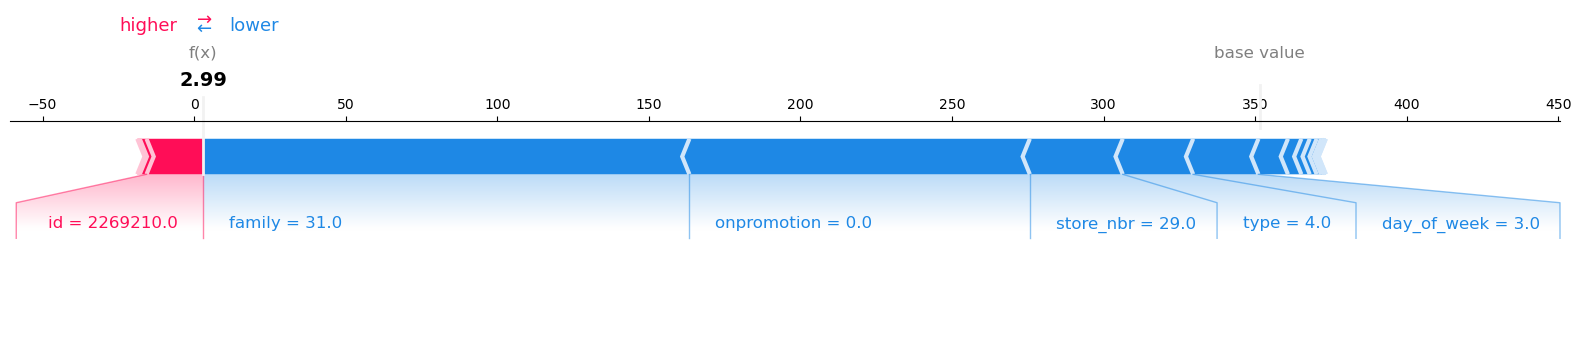

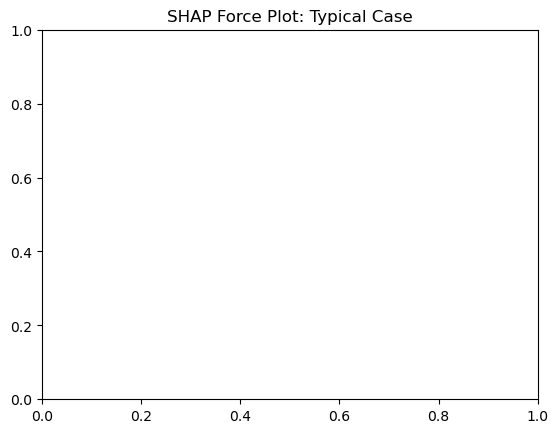

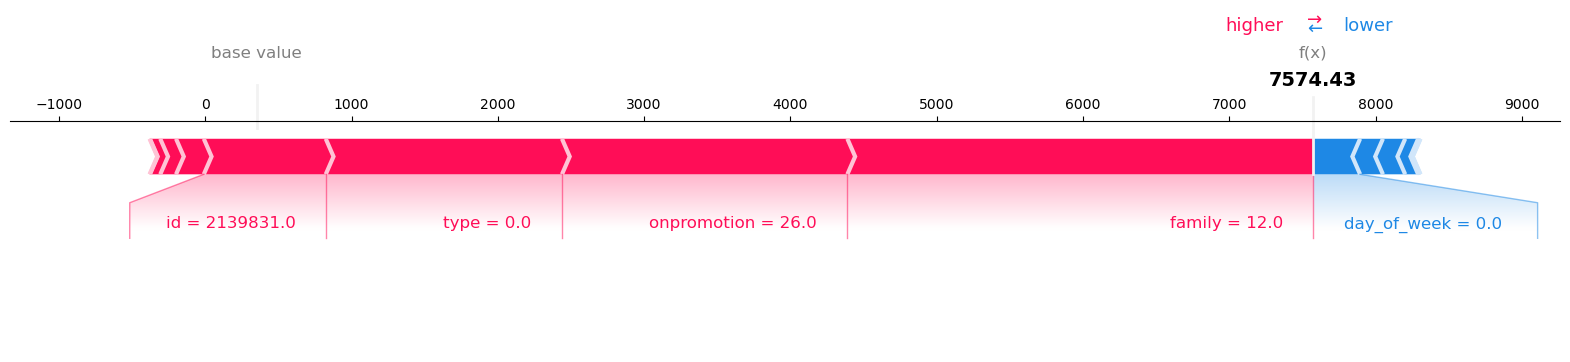

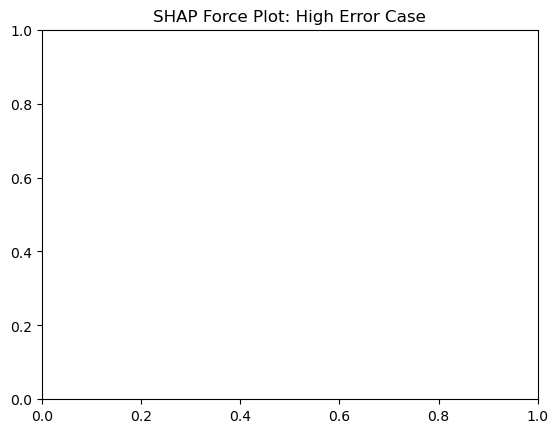

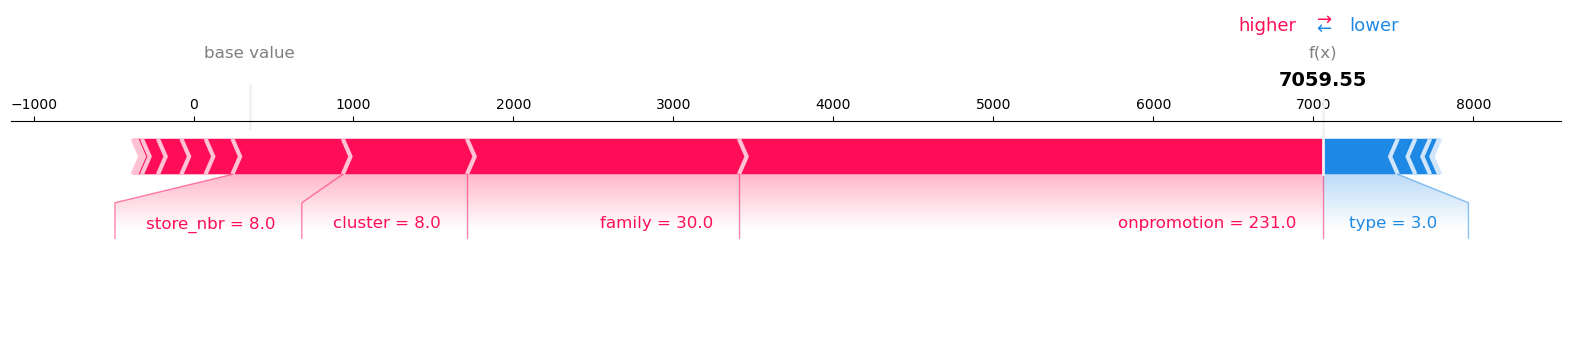

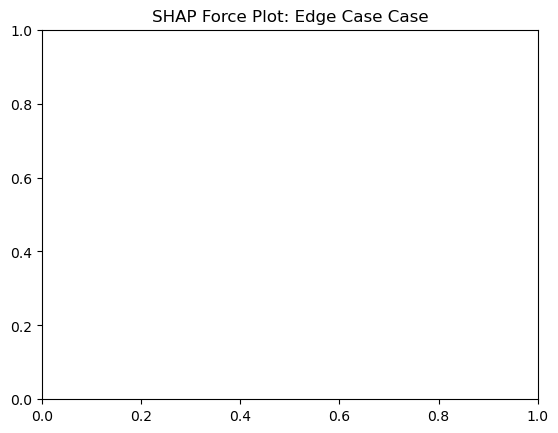

In [28]:

# Generate Force Plots
for name, idx in [("Typical", idx_typical), ("High Error", idx_high_err), ("Edge Case", idx_edge)]:
    shap.plots.force(
        explainer.expected_value,
        shap_values.values[idx],
        X_sample.iloc[idx],
        matplotlib=True
    )
    plt.title(f"SHAP Force Plot: {name} Case", fontsize=12)
    plt.show()

In [14]:
# Task 3


Top 3 SHAP Features: ['family', 'onpromotion', 'type']


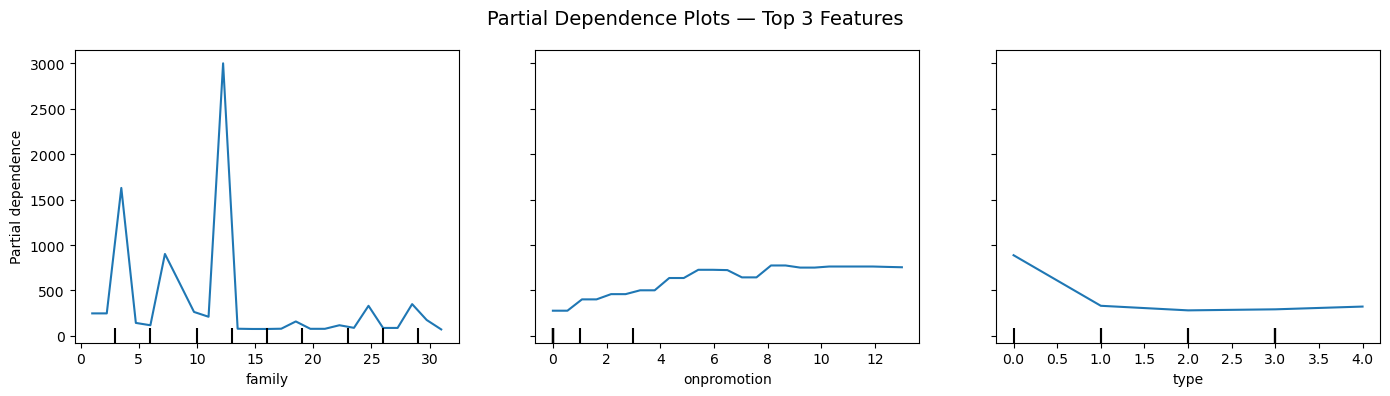

In [16]:
from sklearn.inspection import PartialDependenceDisplay

# Extract top 3 features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_3_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top_3_features = [X_sample.columns[i] for i in top_3_idx]

print("Top 3 SHAP Features:", top_3_features)

# Plot Partial Dependence
fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_sample,
    features=top_3_features,
    grid_resolution=25,
    ax=ax
)
plt.suptitle("Partial Dependence Plots — Top 3 Features", fontsize=14)
plt.tight_layout()
plt.show()

# Day 4: Interpretability Report

### 1. Global Drivers (SHAP Summary)
* **Product Category (`family`):** The single biggest driver. Staple groceries and drinks sell in much higher volumes than niche items.
* **Promotions (`onpromotion`):** High discounts directly boost predicted sales, while zero promotions keep predictions low.
* **Store Type & Days:** Flagship stores (`type = 0`) and weekend days (`day_of_week`) consistently push demand higher.

### 2. Local Predictions (Force Plots)
* **Typical Case:** For a low-demand product with `onpromotion = 0`, the model accurately predicts a near-zero outcome (~3.08 units).
* **High-Error Case:** The model outputs a huge prediction (~7,574 units) driven by heavy promotions and high-velocity item categories, but an arbitrary database ID also pushed the prediction upward.

### 3. Sanity Checks (Partial Dependence)
* **Promotions:** Sales increase smoothly as promotions grow from 0 to ~6 items, then level off. This matches real-world diminishing returns.
* **Store Formats:** Flagship stores have a high sales baseline, dropping sharply for smaller store types (1 to 4).

### 4. Suspicious Findings (Data Leakage Detected)
* **Issue:** The `id` column ranks high in SHAP importance. 
* **Impact:** `id` is just an arbitrary row index. Decision trees are memorizing row numbers rather than real consumer behavior.
* **Action Item:** Drop `id` from training data (`X = df.drop(columns=['sales', 'id'])`) and retrain.